In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

r:\Demand_Intelligence_Engine


In [2]:
from src.components.prediction_manager import PredictionManager

request = {
    "Store": 1,
    "Date": "2015-08-01",
    "Promo": 1,
    "Open": 1,
    "StateHoliday": "0",
    "SchoolHoliday": 0
}


In [3]:
from src.components.prediction_manager import PredictionManager
from src.components.operational_intelligence_engine import (
    OperationalIntelligenceEngine
)
from src.components.business_advisor import BusinessAdvisor

In [4]:
from src.config.configuration import ConfigurationManager

In [5]:
config = ConfigurationManager()

print(config.project_root)

R:\Demand_Intelligence_Engine


In [6]:
manager = PredictionManager()

prediction_result = manager.predict(
    request,
    generate_explanations=True
)

r:\Demand_Intelligence_Engine\src\pipeline\prediction_feature_engineering.py:40: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  self.calendar_data = pd.read_csv(


In [7]:
oie = OperationalIntelligenceEngine()

business_context = (
    oie.generate_operational_intelligence(
        prediction_df=prediction_result["predictions"],
        feature_df=prediction_result["metadata"]["feature_df"],
        store_history_df=prediction_result["metadata"]["store_history_df"],
        sales_explanation=prediction_result["sales_explanation"]
    )
)

print(business_context)

{'demand': {'predicted_sales': np.float32(5291.52), 'predicted_customers': np.float32(586.04), 'historical_avg_sales': np.float64(3868.1), 'historical_avg_customers': np.float64(448.73), 'sales_deviation_percent': np.float64(36.8), 'customer_deviation_percent': np.float64(30.6)}, 'trend': {'sales_trend_percent': np.float64(31.092797665035622), 'customer_trend_percent': np.float64(12.414733969986358)}, 'promotion': {'promo_active': True, 'promo2_active': False, 'promo2_age_months': np.int32(0)}, 'competition': {'competition_distance': np.float64(1270.0), 'competition_age_months': np.int32(83), 'competition_active': True, 'competition_known': True}, 'forecast_context': {'historical_records': 30, 'historical_min_sales': np.int64(0), 'historical_max_sales': np.int64(6102), 'sales_volatility': np.float64(0.4320629917153109), 'competition_context_available': True}, 'explainability': {'shap_values': array([[ 3.57761359e+00, -4.97385483e+01,  3.08202393e+02,
        -1.18240845e+00, -4.9486827

In [8]:
[m for m in dir(oie) if "generate" in m]


['generate_batch_operational_intelligence',
 'generate_operational_intelligence']

In [9]:
advisor = BusinessAdvisor()

In [10]:
summary = advisor.generate_summary(
    business_context
)

print(summary)

{'provider': 'groq', 'model': 'llama-3.3-70b-versatile', 'response': 'Based on the provided business context, the forecast indicates a significant increase in sales and customer traffic, with predicted sales of 5291.52 and predicted customers of 586.04, representing a 36.8% and 30.6% deviation from historical averages, respectively. The sales trend is also positive, with a 31.09% increase, indicating a strong demand. The current promotion is active, which may be contributing to the increased demand. Retail managers should be prepared to handle the higher volume of customers and sales, ensuring adequate staffing and inventory levels to meet the increased demand. Overall, the forecast suggests a busy period ahead, and managers should be proactive in their operational planning to capitalize on the opportunity and minimize any potential disruptions.', 'usage': CompletionUsage(completion_tokens=151, prompt_tokens=2198, total_tokens=2349, completion_tokens_details=None, prompt_tokens_details

In [11]:
recommendations = advisor.generate_recommendations(
    business_context
)

print(recommendations)

{'provider': 'groq', 'model': 'llama-3.3-70b-versatile', 'response': "Based on the provided Business Context, here are five operational recommendations for the retail manager:\n\n1. **Increase staffing levels**: With a predicted 36.8% increase in sales and a 30.6% increase in customer traffic, it is essential to ensure that the store is adequately staffed to handle the expected surge in demand. This will help maintain customer satisfaction and prevent potential losses due to long wait times or unattended customers.\n\n2. **Optimize inventory management**: Although the Business Context does not provide current inventory levels, the predicted sales increase suggests that inventory levels should be reviewed and adjusted accordingly to meet the anticipated demand. This will help prevent stockouts and minimize the risk of overstocking.\n\n3. **Leverage promotional activities**: The Business Context indicates that a promo is currently active, which may be contributing to the predicted sales 

In [12]:
explanation = advisor.explain_prediction(
    business_context,
    "Why are sales expected to increase?"
)

print(explanation)

{'provider': 'groq', 'model': 'llama-3.3-70b-versatile', 'response': "Based on the provided Business Context, sales are expected to increase, with a predicted sales value of 5291.52, which represents a 36.8% deviation from the historical average sales. This increase can be attributed to several key business drivers.\n\nThe data suggests that the number of predicted customers is 586.04, which is a 30.6% deviation from the historical average customers. This increase in customer traffic is likely to contribute to the expected rise in sales.\n\nAdditionally, the sales trend is positive, with a sales trend percentage of 31.09%. This indicates that sales have been increasing over time, which supports the forecast of higher sales.\n\nThe fact that a promotion is currently active (promo_active: true) may also be a contributing factor to the expected increase in sales. However, without more information about the specifics of the promotion, it's difficult to determine its exact impact.\n\nIn ter

In [13]:
answer = advisor.answer_question(
    business_context,
    "Should we increase staffing tomorrow?"
)

print(answer)

{'provider': 'groq', 'model': 'llama-3.3-70b-versatile', 'response': "To answer whether you should increase staffing tomorrow, let's examine the provided Business Context. The predicted sales for tomorrow are 5291.52, and the predicted number of customers is 586.04. This represents a significant increase from the historical averages, with sales deviation at 36.8% and customer deviation at 30.6% above the historical averages.\n\nGiven this context, it appears that tomorrow is expected to be busier than usual, with both higher sales and more customers anticipated. Considering the sales trend is also positive at 31.09%, it suggests a growing demand.\n\nHowever, to make an informed decision about increasing staffing, we would need to know the current staffing levels and how they correlate with customer numbers and sales volumes. Without this information, it's challenging to determine if the current staff can adequately handle the anticipated increase in customers and sales.\n\nTherefore, t

In [14]:
advisor = BusinessAdvisor()

request = advisor.parse_prediction_request(
    "Predict sales for Store 1 tomorrow"
)

print(request)

{'Store': 1, 'Date': '2026-07-10', 'Promo': None, 'Open': None, 'StateHoliday': None, 'SchoolHoliday': None}


In [15]:
print(type(request["Store"]))

<class 'int'>


In [16]:
request = advisor.parse_prediction_request(
    "Predict sales for Store 1 tomorrow"
)

result = manager.predict(
    request,
    generate_explanations=True
)

print(result["predictions"])

        Date  Promo StateHoliday  SchoolHoliday  Store  Open  Year  Month  \
0 2026-07-10      0            0              0      1     1  2026      7   

   Day  DayOfWeek  ...  Sales_Lag_14  Sales_Lag_28  Sales_RollingMean_7  \
0   10          5  ...          4406          4797          4363.142857   

  Sales_RollingMean_14 Sales_RollingMean_28  Sales_RollingStd_7  \
0          3845.714286          3779.285714         1995.703922   

   Sales_RollingStd_14  Sales_RollingStd_28  Predicted_Customers  \
0          1785.199296           1691.90657           520.777405   

   Predicted_Sales  
0      4488.082031  

[1 rows x 49 columns]


In [17]:
advisor.parse_prediction_request(
    "Predict demand for Store 15"
)

{'Store': 15,
 'Date': '2026-07-10',
 'Promo': None,
 'Open': None,
 'StateHoliday': None,
 'SchoolHoliday': None}

In [11]:
from src.config.configuration import ConfigurationManager
from src.pipeline.recursive_forecast_engine import (
    RecursiveForecastEngine
)

config = ConfigurationManager()

engine = RecursiveForecastEngine(
    config.get_recursive_forecast_config()
)

r:\Demand_Intelligence_Engine\src\pipeline\prediction_feature_engineering.py:40: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  self.calendar_data = pd.read_csv(


In [11]:
print(
    engine.prediction_feature_engineering
    .calendar_data
    .columns
    .tolist()
)

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'WeekOfYear']


In [20]:
request = {
    "Store": 1,
    "Date": "2015-08-01",
    "Promo": 1,
    "Open": 1,
    "StateHoliday": "0",
    "SchoolHoliday": 0
}

forecast = engine.forecast(
    request,
    forecast_days=1
)

forecast

{'forecast':         Date  Promo StateHoliday  SchoolHoliday  Store  Open  Year  Month  \
 0 2015-08-01      1            0              0      1     1  2015      8   
 
    Day  DayOfWeek  ...  Sales_Lag_14  Sales_Lag_28  Sales_RollingMean_7  \
 0    1          6  ...          4406          4797          4363.142857   
 
   Sales_RollingMean_14 Sales_RollingMean_28  Sales_RollingStd_7  \
 0          3845.714286          3779.285714         1995.703922   
 
    Sales_RollingStd_14  Sales_RollingStd_28  Predicted_Customers  \
 0          1785.199296           1691.90657           586.041443   
 
    Predicted_Sales  
 0      5291.523438  
 
 [1 rows x 49 columns],
 'manager_forecast':         Date  Store  Promo  Open  Predicted_Customers  Predicted_Sales
 0 2015-08-01      1      1     1           586.041443      5291.523438}

In [21]:
engine.prediction_feature_engineering.historical_data.columns.tolist()

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'SchoolHoliday',
 'CompetitionDistance',
 'Promo2',
 'Year',
 'Month',
 'Quarter',
 'Day',
 'WeekOfYear',
 'IsWeekend',
 'IsMonthStart',
 'IsMonthEnd',
 'IsQuarterStart',
 'IsQuarterEnd',
 'CompetitionAgeMonths',
 'CompetitionDateKnown',
 'CompetitionActive',
 'Promo2AgeMonths',
 'Promo2Active',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_b',
 'Assortment_c',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'Sales_Lag_7',
 'Sales_Lag_14',
 'Sales_Lag_28',
 'Sales_RollingMean_7',
 'Sales_RollingMean_14',
 'Sales_RollingMean_28',
 'Sales_RollingStd_7',
 'Sales_RollingStd_14',
 'Sales_RollingStd_28',
 'Customers_Lag_7',
 'Customers_Lag_14',
 'Customers_Lag_28',
 'Customers_RollingMean_7',
 'Customers_RollingMean_14',
 'Customers_RollingMean_28',
 'Customers_RollingStd_7',
 'Customers_RollingStd_14',
 'Customers_RollingStd_28']

In [22]:
forecast = engine.forecast(
    request,
    forecast_days=7
)

forecast[
    [
        "Date",
        "Predicted_Customers",
        "Predicted_Sales"
    ]
]

TypeError: unhashable type: 'list'

In [23]:
type(forecast)

dict

In [24]:
forecast.keys()

dict_keys(['forecast', 'manager_forecast'])

In [25]:
forecast["forecast"][
    [
        "Date",
        "Predicted_Customers",
        "Predicted_Sales"
    ]
]

,Date,Predicted_Customers,Predicted_Sales
0,2015-08-01,586.041443,5291.523438
1,2015-08-02,212.820770,1669.697144
2,2015-08-03,530.148376,4505.098145
3,2015-08-04,499.470795,4078.609131
4,2015-08-05,473.003296,3891.777832
5,2015-08-06,490.942139,3993.076172
6,2015-08-07,465.587006,3883.424316


In [27]:
calendar_data = (
    engine
    .prediction_feature_engineering
    .calendar_data
)

In [28]:
calendar_data.groupby(
    ["Store", "DayOfWeek"]
)["Open"].mean().reset_index()

,Store,DayOfWeek,Open
0,1,1,0.955224
1,1,2,0.992593
2,1,3,0.977778
3,1,4,0.918519
4,1,5,0.955556
...,...,...,...
7800,1115,3,0.977778
7801,1115,4,0.918519
7802,1115,5,0.955556
7803,1115,6,1.000000


In [29]:
(
    calendar_data
    .groupby(["Store", "DayOfWeek"])["Open"]
    .mean()
    .reset_index()
    .query("Open == 0")
)

,Store,DayOfWeek,Open
6,1,7,0.0
13,2,7,0.0
20,3,7,0.0
27,4,7,0.0
34,5,7,0.0
...,...,...,...
7776,1111,7,0.0
7783,1112,7,0.0
7790,1113,7,0.0
7797,1114,7,0.0


In [30]:
calendar_data["Month"] = (
    calendar_data["Date"].dt.month
)

calendar_data["Day"] = (
    calendar_data["Date"].dt.day
)

In [31]:
(
    calendar_data
    .groupby(["Month", "Day"])["Open"]
    .mean()
    .sort_values()
    .head(20)
)

Month  Day
1      1      0.015849
12     25     0.016098
5      1      0.017339
12     26     0.018537
10     3      0.038537
3      29     0.346786
4      6      0.350673
       21     0.351868
5      25     0.351868
6      9      0.352765
11     17     0.464390
       10     0.464390
12     1      0.464390
       15     0.464390
11     24     0.464390
12     8      0.464878
11     3      0.464878
12     29     0.468293
9      1      0.468780
       8      0.469268
Name: Open, dtype: float64

In [32]:
weekly_closures = (
    calendar_data
    .groupby(["Store", "DayOfWeek"])["Open"]
    .mean()
    .reset_index()
)

weekly_closures[
    weekly_closures["Open"] == 0
]

,Store,DayOfWeek,Open
6,1,7,0.0
13,2,7,0.0
20,3,7,0.0
27,4,7,0.0
34,5,7,0.0
...,...,...,...
7776,1111,7,0.0
7783,1112,7,0.0
7790,1113,7,0.0
7797,1114,7,0.0


In [33]:
calendar_data.groupby(
    "DayOfWeek"
)["Open"].mean()

DayOfWeek
1    0.950459
2    0.988309
3    0.974400
4    0.923199
5    0.950598
6    0.995357
7    0.024826
Name: Open, dtype: float64

In [34]:
weekly_closures[
    weekly_closures["Open"] == 0
]

,Store,DayOfWeek,Open
6,1,7,0.0
13,2,7,0.0
20,3,7,0.0
27,4,7,0.0
34,5,7,0.0
...,...,...,...
7776,1111,7,0.0
7783,1112,7,0.0
7790,1113,7,0.0
7797,1114,7,0.0


In [12]:
import pandas as pd
import numpy as np  

In [13]:
test_df = pd.read_csv(
    r"R:\Demand_Intelligence_Engine\data\raw\rossmann\test.csv",
    parse_dates=["Date"]
)

test_df.shape

(41088, 8)

In [14]:
sample_df = (
    test_df
    .sample(
        n=10,
        random_state=42
    )
    .reset_index(drop=True)
)

In [15]:
request_df = sample_df[
    [
        "Store",
        "Date",
        "Promo",
        "Open",
        "StateHoliday",
        "SchoolHoliday"
    ]
].copy()

In [16]:
manager = PredictionManager()

results = manager.predict(
    request_df,
    generate_explanations=False
)

r:\Demand_Intelligence_Engine\src\pipeline\prediction_feature_engineering.py:40: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  self.calendar_data = pd.read_csv(


In [17]:
results["predictions"].head()

,Date,Promo,StateHoliday,SchoolHoliday,Store,Open,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
0,2015-08-14,0,0,1,69,1,2015,8,14,5,...,7540,6638,8779.000000,7924.500000,7860.250000,4091.433286,3628.080500,3557.859257,952.297668,7255.048828
1,2015-09-12,0,0,0,468,1,2015,9,12,6,...,7415,7283,7404.285714,6050.571429,5704.678571,3364.207223,3115.041961,2778.190246,846.590149,7890.942383
2,2015-09-07,0,0,1,728,1,2015,9,7,1,...,6435,5874,5471.857143,4842.714286,4739.714286,2446.630569,2250.264956,2114.743323,469.638428,5087.792480
3,2015-08-21,1,0,0,426,1,2015,8,21,5,...,3500,3431,4630.714286,3955.142857,4056.214286,2287.835492,1982.623005,1975.918733,591.062805,4814.830566
4,2015-08-25,0,0,1,275,1,2015,8,25,2,...,7049,6457,6929.428571,5927.785714,5765.964286,3204.650832,2864.679044,2714.313207,648.746643,5849.674805


In [18]:
results["predictions"].shape

(10, 49)

In [19]:
results["predictions"].isna().sum()

Date                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
Store                        0
Open                         0
Year                         0
Month                        0
Day                          0
DayOfWeek                    0
WeekOfYear                   0
Quarter                      0
IsWeekend                    0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                3
CompetitionOpenDate          0
CompetitionAgeMonths         0
CompetitionDateKnown         0
CompetitionActive            0
Promo2StartDate              0
Promo2AgeMonths              0
Promo2Active                 0
Customers_Lag_7              0
Customers_Lag_14             0
Customers_Lag_28             0
Customer

In [20]:
results["predictions"][
    "Predicted_Sales"
].describe()

count      10.000000
mean     6412.186133
std      2980.383916
min         0.000000
25%      4883.071045
50%      6552.361816
75%      8588.053467
max      9812.321289
Name: Predicted_Sales, dtype: float64

In [21]:
results["predictions"][
    "Predicted_Customers"
].describe()

count     10.000000
mean     661.386249
std      278.195572
min        0.000000
25%      594.806900
50%      716.936554
75%      839.151978
max      952.297668
Name: Predicted_Customers, dtype: float64

In [22]:
(
    results["predictions"]["Predicted_Sales"] < 0
).sum()

np.int64(0)

In [23]:
(
    results["predictions"]["Predicted_Customers"] < 0
).sum()

np.int64(0)

In [24]:
closed_predictions = (
    results["predictions"]
    .loc[
        request_df["Open"] == 0
    ]
)

closed_predictions.head()

,Date,Promo,StateHoliday,SchoolHoliday,Store,Open,Year,Month,Day,DayOfWeek,...,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28,Predicted_Customers,Predicted_Sales
9,2015-08-16,0,0,0,1057,0,2015,8,16,7,...,6567,6166,5754.142857,4969.857143,5222.142857,2618.344479,2401.313899,2380.465278,0.0,0.0


In [25]:
%%time

results = manager.predict(
    request_df,
    generate_explanations=True
)

CPU times: total: 10.6 s
Wall time: 3.24 s


In [26]:
len(results["metadata"])

10

In [27]:
single = manager.predict(
    request_df.iloc[0].to_dict(),
    generate_explanations=True
)

In [28]:
single.keys()

dict_keys(['predictions', 'customer_explanation', 'sales_explanation', 'combined_explanation', 'metadata'])

In [29]:
single["combined_explanation"].keys()

dict_keys(['customer', 'sales'])

In [30]:
results.keys()

dict_keys(['predictions', 'explanations', 'metadata', 'batch_explanation'])

In [31]:
results["predictions"].shape

(10, 49)

In [32]:
len(results["explanations"])

10

In [33]:
len(results["metadata"])

10

In [34]:
results["batch_explanation"]

{'feature_importance':                      Feature   Mean_SHAP
 23       Predicted_Customers  848.987183
 24                     Promo  470.614685
 29              Sales_Lag_14  379.742737
 33      Sales_RollingMean_28  318.862671
 32      Sales_RollingMean_14  196.049423
 30              Sales_Lag_28  156.810837
 34       Sales_RollingMean_7  148.091385
 37        Sales_RollingStd_7  140.367874
 16                 DayOfWeek  100.286781
 10  Customers_RollingMean_28   91.873535
 6           Customers_Lag_14   74.898666
 13   Customers_RollingStd_28   73.725586
 15                       Day   70.575569
 11   Customers_RollingMean_7   64.583878
 45               StoreType_d   59.035278
 9   Customers_RollingMean_14   58.538357
 46                WeekOfYear   54.009857
 5        CompetitionDistance   44.165020
 14    Customers_RollingStd_7   31.891195
 47                      Year   31.536251
 7           Customers_Lag_28   30.883829
 31               Sales_Lag_7   28.806654
 35       Sa

In [35]:
results["batch_explanation"].keys()

dict_keys(['feature_importance', 'top_features'])

In [36]:
results["batch_explanation"]["top_features"]

,Feature,Mean_SHAP
23,Predicted_Customers,848.987183
24,Promo,470.614685
29,Sales_Lag_14,379.742737
33,Sales_RollingMean_28,318.862671
32,Sales_RollingMean_14,196.049423
30,Sales_Lag_28,156.810837
34,Sales_RollingMean_7,148.091385
37,Sales_RollingStd_7,140.367874
16,DayOfWeek,100.286781
10,Customers_RollingMean_28,91.873535


In [37]:
results["predictions"].isna().sum()

Date                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
Store                        0
Open                         0
Year                         0
Month                        0
Day                          0
DayOfWeek                    0
WeekOfYear                   0
Quarter                      0
IsWeekend                    0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                3
CompetitionOpenDate          0
CompetitionAgeMonths         0
CompetitionDateKnown         0
CompetitionActive            0
Promo2StartDate              0
Promo2AgeMonths              0
Promo2Active                 0
Customers_Lag_7              0
Customers_Lag_14             0
Customers_Lag_28             0
Customer

In [38]:
(
    results["predictions"]["Predicted_Sales"] < 0
).sum()

np.int64(0)

In [39]:
(
    results["predictions"]["Predicted_Customers"] < 0
).sum()

np.int64(0)

In [40]:
closed_predictions = (
    results["predictions"]
    .loc[
        request_df["Open"] == 0
    ]
)

closed_predictions[
    [
        "Date",
        "Open",
        "Predicted_Customers",
        "Predicted_Sales"
    ]
]

,Date,Open,Predicted_Customers,Predicted_Sales
9,2015-08-16,0,0.0,0.0


In [41]:
results["predictions"][
    [
        "Predicted_Customers",
        "Predicted_Sales"
    ]
].describe()

,Predicted_Customers,Predicted_Sales
count,10.000000,10.000000
mean,661.386249,6412.186133
std,278.195572,2980.383916
min,0.000000,0.000000
25%,594.806900,4883.071045
50%,716.936554,6552.361816
75%,839.151978,8588.053467
max,952.297668,9812.321289


In [42]:
results["batch_explanation"][
    "feature_importance"
].head(20)

,Feature,Mean_SHAP
23,Predicted_Customers,848.987183
24,Promo,470.614685
29,Sales_Lag_14,379.742737
33,Sales_RollingMean_28,318.862671
32,Sales_RollingMean_14,196.049423
30,Sales_Lag_28,156.810837
34,Sales_RollingMean_7,148.091385
37,Sales_RollingStd_7,140.367874
16,DayOfWeek,100.286781
10,Customers_RollingMean_28,91.873535


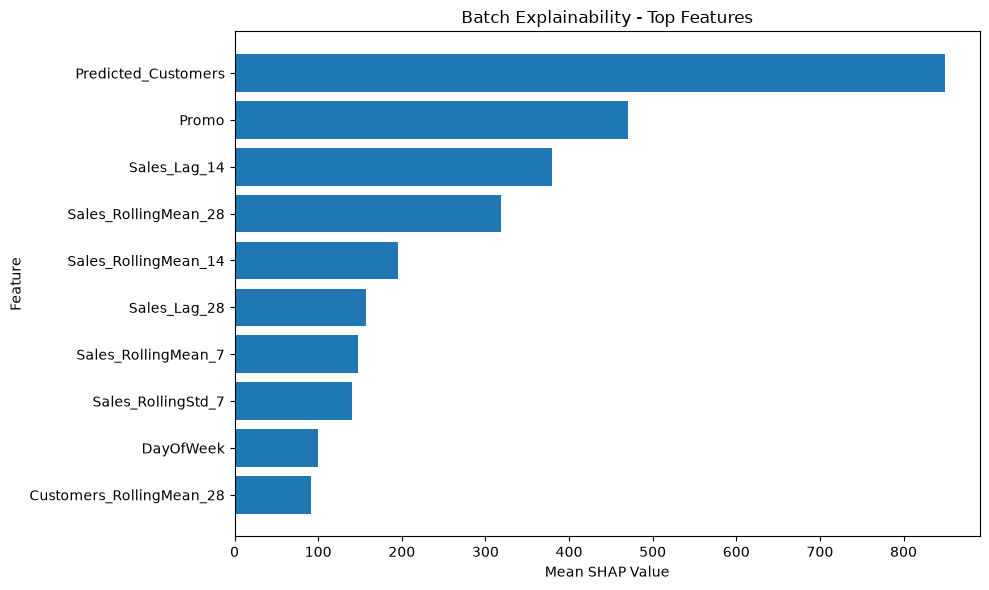

In [43]:
import matplotlib.pyplot as plt

top_features = (
    results["batch_explanation"]
    ["top_features"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean_SHAP"][::-1]
)

plt.xlabel("Mean SHAP Value")
plt.ylabel("Feature")
plt.title("Batch Explainability - Top Features")
plt.tight_layout()
plt.show()

In [44]:
batch_context = {
    "predictions":
        results["predictions"][
            [
                "Store",
                "Date",
                "Promo",
                "Open",
                "Predicted_Customers",
                "Predicted_Sales"
            ]
        ].to_dict(
            orient="records"
        ),
    "batch_explanation":
        results["batch_explanation"]
}

In [45]:
advisor.generate_summary(
    batch_context
)

{'provider': 'groq',
 'model': 'llama-3.3-70b-versatile',
 'response': 'Based on the forecast, we expect varying customer traffic and sales across different stores, with predicted customer counts ranging from 469 to 952 and sales ranging from $4,806 to $9,812. Notably, Store 64 is predicted to have the highest sales, at $9,812, on August 22, 2015, while Store 1057 is expected to have no customers or sales on August 16, 2015, as it will be closed. The data suggests that the number of predicted customers is a key driver of sales, with a strong positive correlation between the two. Retail managers should be prepared to manage inventory and staffing levels accordingly, taking into account the predicted fluctuations in customer traffic and sales. Overall, the forecast highlights the importance of being prepared for varying demand levels across different stores and dates.',
 'usage': CompletionUsage(completion_tokens=169, prompt_tokens=2072, total_tokens=2241, completion_tokens_details=None,

In [46]:
oie = OperationalIntelligenceEngine()

batch_context = (
    oie.generate_batch_operational_intelligence(
        prediction_df=results["predictions"],
        batch_explanation=results["batch_explanation"]
    )
)

In [47]:
batch_context.keys()

dict_keys(['summary', 'promotion', 'top_stores', 'forecast_context', 'explainability'])

In [48]:
advisor = BusinessAdvisor()

summary = advisor.generate_summary(
    batch_context
)

print(
    summary["response"]
)

Based on the forecast, the total predicted sales across all stores is $64,121.86, with an average of $6,412.19 per store. The top-performing stores are expected to drive significant sales, with Store 64 predicted to generate $9,812.32 in sales. The forecast also indicates that two stores will be running promotions, which may impact sales performance. Overall, the forecast suggests a relatively stable demand environment, with no major changes or trends evident in the data. Retail managers should focus on optimizing operations in the top-performing stores and monitoring the impact of promotions to maximize sales potential.


In [49]:
recommendations = (
    advisor.generate_recommendations(
        batch_context
    )
)

print(
    recommendations["response"]
)

Based on the provided Business Context, here are 5 operational recommendations for the retail manager:

1. **Focus on high-potential stores**: The top stores list shows that Store 64, Store 694, and Store 1010 have the highest predicted sales. Consider allocating additional resources or attention to these stores to maximize sales potential.
2. **Leverage promotions effectively**: The promotion data indicates that 2 stores have active promotions with a 20% discount. Ensure that these promotions are well-communicated to customers and that stores are prepared to handle potential increases in sales volume.
3. **Optimize staffing for customer traffic**: The predicted customer traffic varies across stores, with some stores expecting significantly more customers than others. Consider adjusting staffing levels to match predicted customer traffic to ensure a smooth customer experience.
4. **Monitor sales performance**: The forecast context provides sales and customer standards. Regularly review

In [50]:
answer = advisor.answer_question(
    batch_context,
    """
    What are the key business insights from these forecasts
    and what actions should management take?
    """
)

print(
    answer["response"]
)

Based on the provided Business Context, the key business insights from these forecasts are:

1. **Total Predicted Sales**: The total predicted sales across all stores is $64,121.86, with an average predicted sales of $6,412.19 per store.
2. **Store Performance**: The top-performing stores are Store 64, Store 694, and Store 1010, with predicted sales of $9,812.32, $9,784.21, and $8,820.42, respectively.
3. **Promotions**: There are currently promotions active in 2 stores, with a promo percentage of 20%. Store 694 and Store 426 are the stores with active promotions.
4. **Customer Traffic**: The total predicted customers across all stores is 6,613.86, with an average predicted customer count of 661.39 per store.

Based on these insights, management should consider the following actions:

1. **Monitor Store Performance**: Closely monitor the performance of the top-performing stores to identify best practices and areas for improvement.
2. **Optimize Promotions**: Evaluate the effectiveness 

In [51]:
answer = advisor.answer_question(
    batch_context,
    """
    Which stores should receive additional inventory
    and why?
    """
)

print(
    answer["response"]
)

To determine which stores should receive additional inventory, we need to analyze the sales forecasts and other relevant information provided in the Business Context.

The top stores by predicted sales are:

1. Store 64: $9,812.32
2. Store 694: $9,784.21
3. Store 1010: $8,820.42
4. Store 468: $7,890.94
5. Store 69: $7,255.05

These stores have the highest predicted sales, indicating a higher demand for products. Additionally, two stores (Store 694 and Store 426) have an active promotion with a 20% discount, which may also impact inventory needs.

However, to make a more informed decision about inventory allocation, we would need more information about the current inventory levels, supplier lead times, and shipping schedules. Without this information, it's challenging to provide a definitive answer on which stores should receive additional inventory.

Based on the available data, we can suggest that stores with higher predicted sales, such as Store 64 and Store 694, may require more inv

In [12]:
request = {
    "Store": 1,
    "Date": "2015-08-01",
    "Promo": 0,
    "StateHoliday": "0",
    "SchoolHoliday": 0
}

In [13]:
forecast = engine.forecast(
    request,
    forecast_days=2
)

Current Request:
{'Store': 1, 'Date': '2015-08-01', 'Promo': 0, 'StateHoliday': '0', 'SchoolHoliday': 0}
--------------------------------------------------


KeyError: 'Open'